<a href="https://colab.research.google.com/github/tarishanaila/2025_pengolahan_citra_TI-2B/blob/main/jb5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TARISHA NAILA ANGELIN
# TI-2B
# 4.33.23.1.23



Pratikum 1

Jarak Euclidean antara Patch 1 dan Patch 2: 24.7650
Jarak Euclidean antara Patch 1 dan Patch 3: 5.0000
Jarak Manhattan antara Patch 1 dan Patch 2: 936.4392
Jarak Manhattan antara Patch 1 dan Patch 3: 250.0000


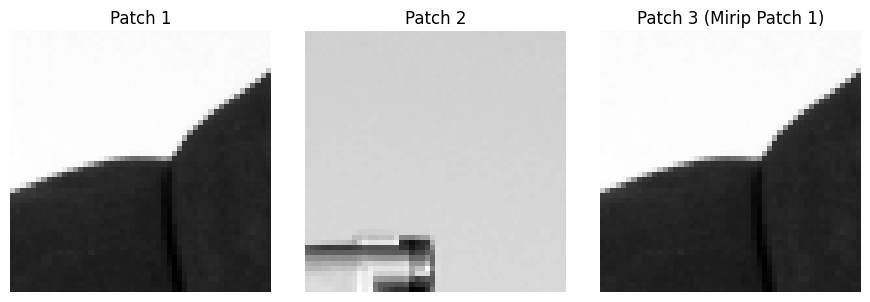

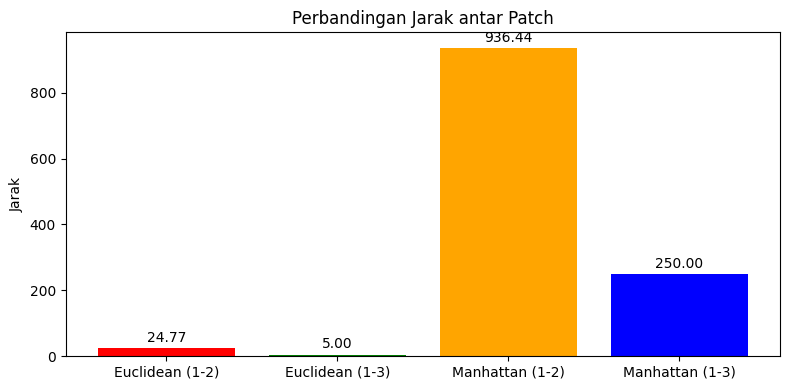

In [1]:
import numpy as np
from skimage import data, img_as_float
from scipy.spatial import distance
import matplotlib.pyplot as plt

# 1. Ambil citra grayscale dan buat 3 patch
image = img_as_float(data.camera())
patch1 = image[100:150, 100:150]
patch2 = image[100:150, 300:350]  # Lokasi berbeda (lebih beda)
patch3 = patch1 + 0.1             # Tambahkan noise (lebih mirip)
patch3 = np.clip(patch3, 0, 1)

# 2. Flatten menjadi vektor
vec1 = patch1.flatten()
vec2 = patch2.flatten()
vec3 = patch3.flatten()

# 3. Hitung jarak
dist_l2_12 = distance.euclidean(vec1, vec2)
dist_l2_13 = distance.euclidean(vec1, vec3)
dist_l1_12 = distance.cityblock(vec1, vec2)
dist_l1_13 = distance.cityblock(vec1, vec3)

# 4. Cetak hasil
print(f"Jarak Euclidean antara Patch 1 dan Patch 2: {dist_l2_12:.4f}")
print(f"Jarak Euclidean antara Patch 1 dan Patch 3: {dist_l2_13:.4f}")
print(f"Jarak Manhattan antara Patch 1 dan Patch 2: {dist_l1_12:.4f}")
print(f"Jarak Manhattan antara Patch 1 dan Patch 3: {dist_l1_13:.4f}")

# 5. Tampilkan patch
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(patch1, cmap='gray')
axes[0].set_title('Patch 1')
axes[0].axis('off')
axes[1].imshow(patch2, cmap='gray')
axes[1].set_title('Patch 2')
axes[1].axis('off')
axes[2].imshow(patch3, cmap='gray')
axes[2].set_title('Patch 3 (Mirip Patch 1)')
axes[2].axis('off')
plt.tight_layout()
plt.show()

# 6. Visualisasi grafik jarak
labels = ['Euclidean (1-2)', 'Euclidean (1-3)', 'Manhattan (1-2)', 'Manhattan (1-3)']
distances = [dist_l2_12, dist_l2_13, dist_l1_12, dist_l1_13]

plt.figure(figsize=(8, 4))
bars = plt.bar(labels, distances, color=['red', 'green', 'orange', 'blue'])
plt.title('Perbandingan Jarak antar Patch')
plt.ylabel('Jarak')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02*max(distances), f'{yval:.2f}', ha='center')
plt.tight_layout()
plt.show()


Praktikum 2

Hasil Praktikum:
Cosine Similarity antara Image 1 (Astronaut) dan Image 2 (Coffee): 0.8156
Cosine Similarity antara Image 1 (Astronaut) dan Image 3 (Astronaut): 1.0000
Cosine Similarity antara Image 1 (Astronaut) dan Image 4 (Downsampled): 1.0000


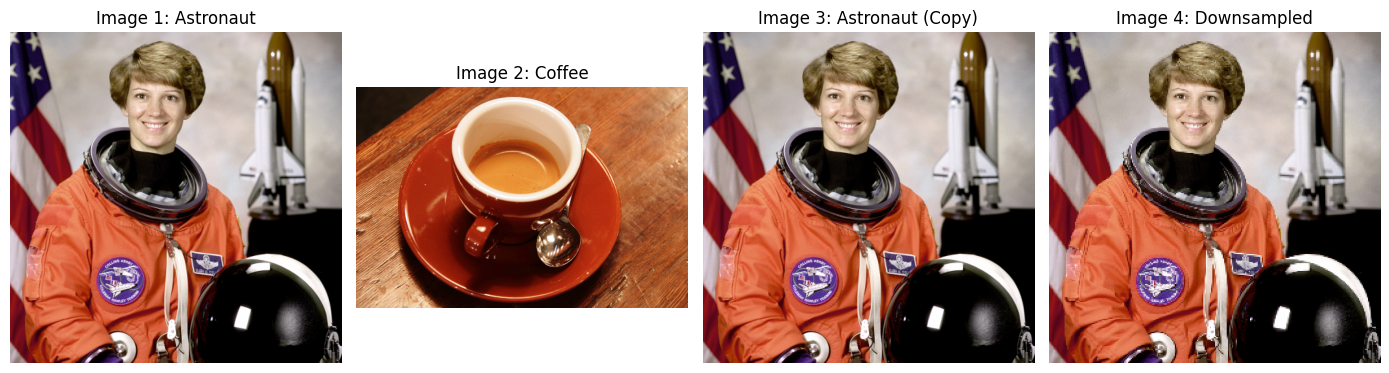

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_ubyte
from scipy.spatial import distance

# Fungsi untuk menghitung histogram RGB gabungan
def calculate_rgb_histogram(image, bins=16):
    img_uint8 = img_as_ubyte(image)
    hist_r, _ = np.histogram(img_uint8[:, :, 0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(img_uint8[:, :, 1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(img_uint8[:, :, 2].ravel(), bins=bins, range=(0, 256))

    # Gabungkan histogram R, G, B
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))
    # Normalisasi
    hist_combined = hist_combined.astype(float) / np.sum(hist_combined)
    return hist_combined

# 1. Muat citra dari skimage
try:
    image1 = data.astronaut()
    image2 = data.coffee()
    image3 = data.astronaut()  # Citra yang sama
    image4 = image1[::2, ::2, :]  # Downsampled dari image1
except Exception as e:
    print(f"Gagal memuat data skimage: {e}. Membuat citra dummy.")
    image1 = np.random.rand(100, 100, 3)
    image2 = np.random.rand(100, 100, 3) * 0.5
    image3 = image1.copy()
    image4 = image1[::2, ::2, :]

# 2. Hitung histogram RGB
hist1 = calculate_rgb_histogram(image1)
hist2 = calculate_rgb_histogram(image2)
hist3 = calculate_rgb_histogram(image3)
hist4 = calculate_rgb_histogram(image4)

# 3. Hitung Cosine Similarity
sim_12 = 1 - distance.cosine(hist1, hist2)
sim_13 = 1 - distance.cosine(hist1, hist3)
sim_14 = 1 - distance.cosine(hist1, hist4)

# 4. Tampilkan hasil Cosine Similarity
print("Hasil Praktikum:")
print(f"Cosine Similarity antara Image 1 (Astronaut) dan Image 2 (Coffee): {sim_12:.4f}")
print(f"Cosine Similarity antara Image 1 (Astronaut) dan Image 3 (Astronaut): {sim_13:.4f}")
print(f"Cosine Similarity antara Image 1 (Astronaut) dan Image 4 (Downsampled): {sim_14:.4f}")

# 5. Visualisasi keempat citra
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes[0].imshow(image1)
axes[0].set_title('Image 1: Astronaut')
axes[0].axis('off')

axes[1].imshow(image2)
axes[1].set_title('Image 2: Coffee')
axes[1].axis('off')

axes[2].imshow(image3)
axes[2].set_title('Image 3: Astronaut (Copy)')
axes[2].axis('off')

axes[3].imshow(image4)
axes[3].set_title('Image 4: Downsampled')
axes[3].axis('off')

plt.tight_layout()
plt.show()


Praktikum 3

Hasil SSIM:
SSIM (Ref vs Same):     1.0000
SSIM (Ref vs Noisy):    0.2944
SSIM (Ref vs Contrast): 0.9651
SSIM (Ref vs Blurred):  0.8027


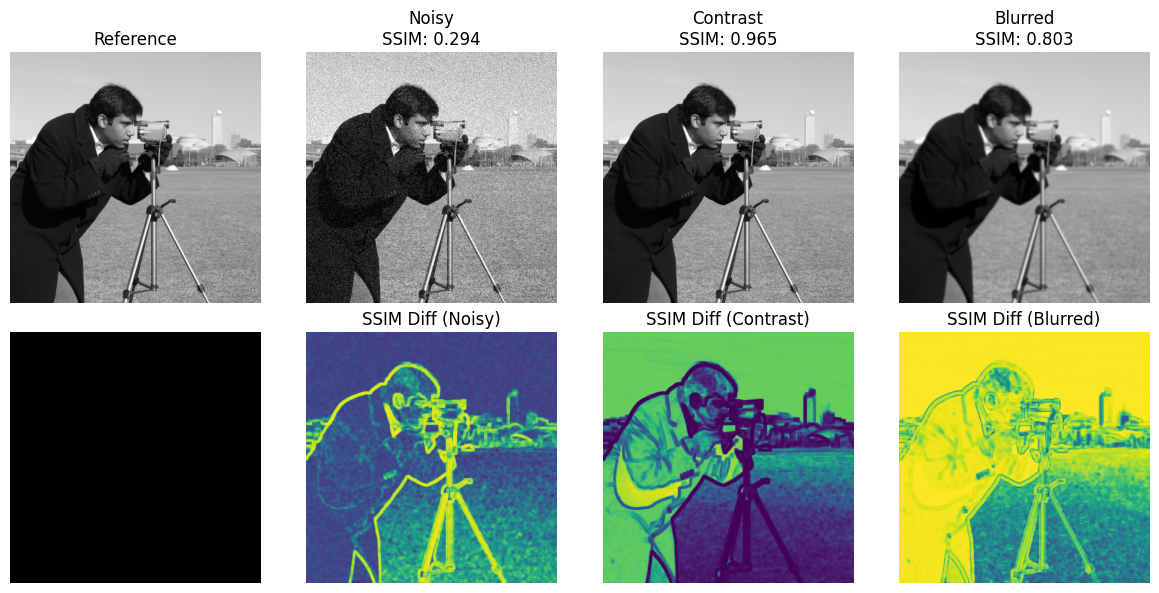

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from skimage.metrics import structural_similarity as ssim
from skimage.transform import resize
from skimage.util import random_noise
from skimage.filters import gaussian

# 1. Muat citra referensi (grayscale)
image_ref = img_as_float(data.camera())

# 2. Buat beberapa versi citra yang 'terdistorsi'
image_same = image_ref.copy()  # a) Citra sama
image_noisy = random_noise(image_ref, mode='gaussian', var=0.01)  # b) Gaussian noise
image_contrast = np.clip(image_ref * 0.8, 0, 1)  # c) Kontras dikurangi
image_blurred = gaussian(image_ref, sigma=1.5, channel_axis=None)  # d) Blur

# 3. Hitung SSIM
data_range = image_ref.max() - image_ref.min()

ssim_same, _ = ssim(image_ref, image_same, data_range=data_range, full=True)
ssim_noisy, diff_noisy = ssim(image_ref, image_noisy, data_range=data_range, full=True)
ssim_contrast, diff_contrast = ssim(image_ref, image_contrast, data_range=data_range, full=True)
ssim_blurred, diff_blurred = ssim(image_ref, image_blurred, data_range=data_range, full=True)

# 4. Tampilkan nilai SSIM
print("Hasil SSIM:")
print(f"SSIM (Ref vs Same):     {ssim_same:.4f}")
print(f"SSIM (Ref vs Noisy):    {ssim_noisy:.4f}")
print(f"SSIM (Ref vs Contrast): {ssim_contrast:.4f}")
print(f"SSIM (Ref vs Blurred):  {ssim_blurred:.4f}")

# 5. Visualisasi citra dan perbedaan SSIM
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
ax = axes.ravel()

# Baris pertama: gambar
ax[0].imshow(image_ref, cmap='gray')
ax[0].set_title('Reference')
ax[1].imshow(image_noisy, cmap='gray')
ax[1].set_title(f'Noisy\nSSIM: {ssim_noisy:.3f}')
ax[2].imshow(image_contrast, cmap='gray')
ax[2].set_title(f'Contrast\nSSIM: {ssim_contrast:.3f}')
ax[3].imshow(image_blurred, cmap='gray')
ax[3].set_title(f'Blurred\nSSIM: {ssim_blurred:.3f}')

# Baris kedua: SSIM difference maps
ax[4].imshow(np.zeros_like(image_ref), cmap='gray')
ax[4].set_title(' ')
ax[5].imshow(diff_noisy, cmap='viridis')
ax[5].set_title('SSIM Diff (Noisy)')
ax[6].imshow(diff_contrast, cmap='viridis')
ax[6].set_title('SSIM Diff (Contrast)')
ax[7].imshow(diff_blurred, cmap='viridis')
ax[7].set_title('SSIM Diff (Blurred)')

for a in ax:
    a.axis('off')

plt.tight_layout()
plt.show()


Praktikum 4

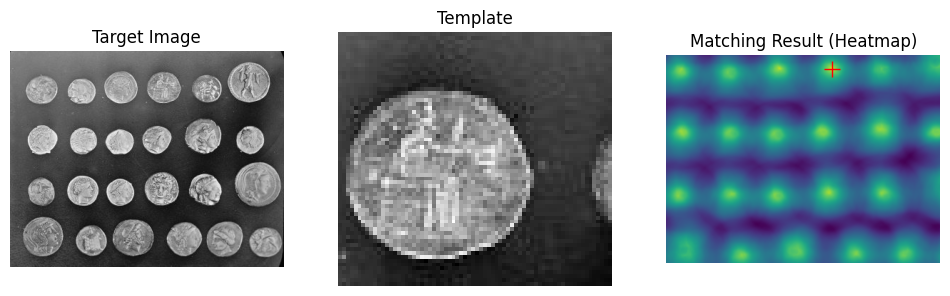

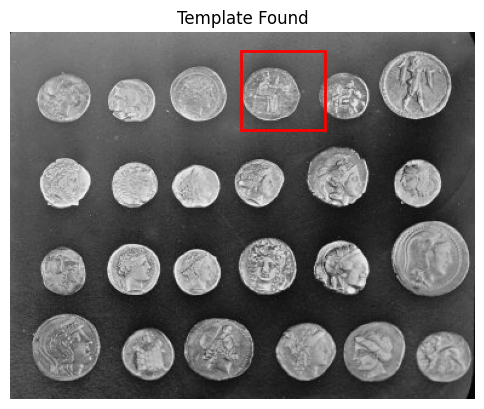

Template ditemukan di koordinat (x, y): (190, 15)


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import match_template

# 1. Muat citra target dan template
image = data.coins()
template = image[15:80, 190:260]  # Potong salah satu koin sebagai template

# 2. Lakukan template matching (Normalized Cross-Correlation)
result = match_template(image, template)

# 3. Temukan lokasi dengan skor matching tertinggi
ij = np.unravel_index(np.argmax(result), result.shape)
x, y = ij[::-1]  # Balik jadi (x, y)

# 4. Visualisasi
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].imshow(image, cmap='gray')
ax[0].set_title('Target Image')
ax[0].axis('off')

ax[1].imshow(template, cmap='gray')
ax[1].set_title('Template')
ax[1].axis('off')

ax[2].imshow(result, cmap='viridis')
ax[2].set_title('Matching Result (Heatmap)')
ax[2].axis('off')
ax[2].plot(x, y, 'r+', markersize=12)

# Kotak di citra asli
fig2, ax_main = plt.subplots(figsize=(6, 6))
ax_main.imshow(image, cmap='gray')
ax_main.set_title('Template Found')
ax_main.axis('off')
h, w = template.shape
rect = plt.Rectangle((x, y), w, h, edgecolor='r', facecolor='none', lw=2)
ax_main.add_patch(rect)

plt.show()

# Output lokasi
print(f"Template ditemukan di koordinat (x, y): ({x}, {y})")


Praktikum 5

Memproses database citra...
- astronaut diproses.
- camera diproses.
- coffee diproses.
- coins diproses.
- chelsea diproses.

Hasil Retrieval (semakin ke kanan, semakin tidak mirip):
Rank 1: chelsea (Distance: 0.000)
Rank 2: coins (Distance: 0.288)
Rank 3: coffee (Distance: 0.359)
Rank 4: astronaut (Distance: 0.461)
Rank 5: camera (Distance: 0.602)


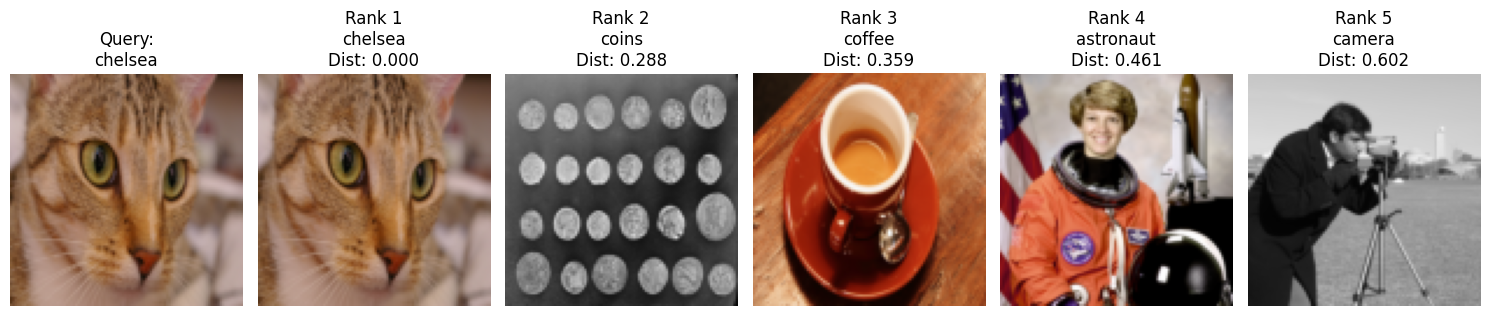

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform, img_as_float, img_as_ubyte
from scipy.spatial import distance

# Fungsi hitung histogram RGB
def calculate_rgb_histogram(image, bins=16):
    # Konversi float [0,1] ke uint8 [0,255]
    if image.dtype == float:
        image = img_as_ubyte(image)
    hist_r, _ = np.histogram(image[:, :, 0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(image[:, :, 1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(image[:, :, 2].ravel(), bins=bins, range=(0, 256))
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))

    # Normalisasi L1 (jumlah total 1)
    hist_sum = np.sum(hist_combined)
    if hist_sum > 0:
        hist_combined = hist_combined.astype(float) / hist_sum
    else:
        hist_combined = hist_combined.astype(float)  # Hindari pembagian nol
    return hist_combined

# 1. Siapkan database citra
image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
database_hists = []

print("Memproses database citra...")
for name in image_db_names:
    try:
        img = getattr(data, name)()
        if img.ndim == 2:  # Jika grayscale, konversi ke RGB
            img = color.gray2rgb(img)
        img_resized = transform.resize(img, (100, 100), anti_aliasing=True)
        database_images.append(img_resized)
        database_hists.append(calculate_rgb_histogram(img_resized))
        print(f"- {name} diproses.")
    except Exception as e:
        print(f"Error memproses {name}: {e}")

# 2. Pilih query image
query_image_name = "chelsea"
query_index = image_db_names.index(query_image_name)
query_image = database_images[query_index]
query_hist = database_hists[query_index]

# 3. Hitung jarak cosine ke semua citra database
distances = []
for i, hist in enumerate(database_hists):
    dist = distance.cosine(query_hist, hist)
    distances.append(dist)

# 4. Urutkan berdasarkan jarak terkecil
sorted_indices = np.argsort(distances)

# 5. Tampilkan hasil
num_results_to_show = len(database_images)
fig, axes = plt.subplots(1, num_results_to_show + 1, figsize=(15, 4))

# Tampilkan query image
axes[0].imshow(query_image)
axes[0].set_title(f"Query:\n{query_image_name}")
axes[0].axis('off')

# Tampilkan hasil retrieval
print("\nHasil Retrieval (semakin ke kanan, semakin tidak mirip):")
for rank, idx in enumerate(sorted_indices):
    ax = axes[rank + 1]
    ax.imshow(database_images[idx])
    ax.set_title(f"Rank {rank+1}\n{image_db_names[idx]}\nDist: {distances[idx]:.3f}")
    ax.axis('off')
    print(f"Rank {rank+1}: {image_db_names[idx]} (Distance: {distances[idx]:.3f})")

plt.tight_layout()
plt.show()


Tugas 1

Memproses database citra...
- astronaut diproses.
- camera diproses.
- coffee diproses.
- coins diproses.
- chelsea diproses.

Hasil Retrieval (semakin ke kanan, semakin tidak mirip):
Rank 1: chelsea (Distance: 0.000)
Rank 2: astronaut (Distance: 0.050)
Rank 3: coffee (Distance: 0.176)
Rank 4: camera (Distance: 0.194)
Rank 5: coins (Distance: 0.211)


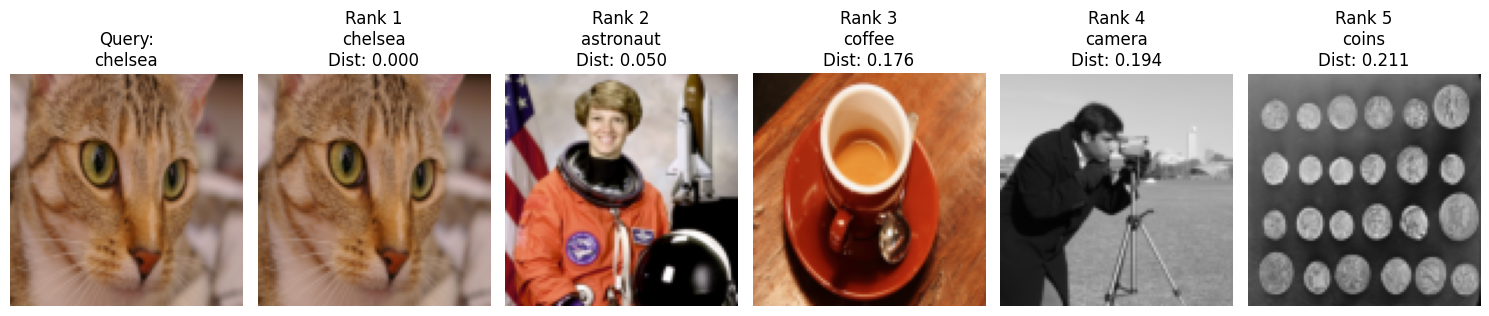

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform, img_as_float, img_as_ubyte
from scipy.spatial import distance

# Fungsi hitung rata-rata warna RGB
def calculate_rgb_mean(image):
    # Menghitung rata-rata warna untuk setiap channel R, G, B
    mean_r = np.mean(image[:, :, 0])
    mean_g = np.mean(image[:, :, 1])
    mean_b = np.mean(image[:, :, 2])
    return np.array([mean_r, mean_g, mean_b])

# 1. Siapkan database citra
image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
database_means = []

print("Memproses database citra...")
for name in image_db_names:
    try:
        img = getattr(data, name)()
        if img.ndim == 2:  # Jika grayscale, konversi ke RGB
            img = color.gray2rgb(img)
        img_resized = transform.resize(img, (100, 100), anti_aliasing=True)
        database_images.append(img_resized)
        database_means.append(calculate_rgb_mean(img_resized))
        print(f"- {name} diproses.")
    except Exception as e:
        print(f"Error memproses {name}: {e}")

# 2. Pilih query image
query_image_name = "chelsea"
query_index = image_db_names.index(query_image_name)
query_image = database_images[query_index]
query_mean = database_means[query_index]

# 3. Hitung jarak Euclidean (L2) ke semua citra database
distances = []
for mean in database_means:
    dist = distance.euclidean(query_mean, mean)
    distances.append(dist)

# 4. Urutkan berdasarkan jarak terkecil
sorted_indices = np.argsort(distances)

# 5. Tampilkan hasil
num_results_to_show = len(database_images)
fig, axes = plt.subplots(1, num_results_to_show + 1, figsize=(15, 4))

# Tampilkan query image
axes[0].imshow(query_image)
axes[0].set_title(f"Query:\n{query_image_name}")
axes[0].axis('off')

# Tampilkan hasil retrieval
print("\nHasil Retrieval (semakin ke kanan, semakin tidak mirip):")
for rank, idx in enumerate(sorted_indices):
    ax = axes[rank + 1]
    ax.imshow(database_images[idx])
    ax.set_title(f"Rank {rank+1}\n{image_db_names[idx]}\nDist: {distances[idx]:.3f}")
    ax.axis('off')
    print(f"Rank {rank+1}: {image_db_names[idx]} (Distance: {distances[idx]:.3f})")

plt.tight_layout()
plt.show()


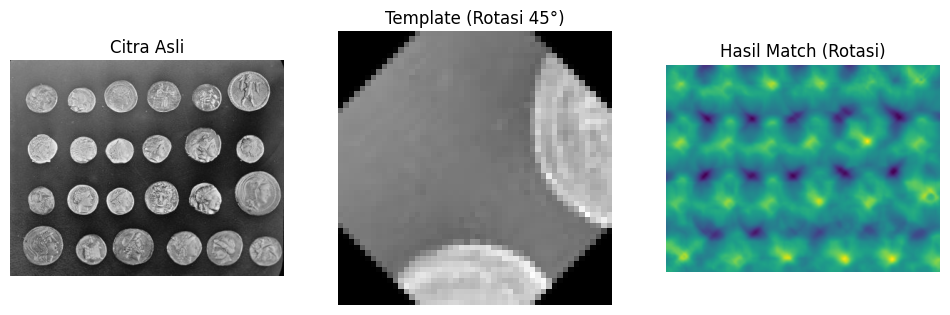

In [7]:
from skimage import data, transform
import matplotlib.pyplot as plt
from skimage.feature import match_template

# Muat citra dan template
image = data.coins()
template = image[10:60, 100:150]

# Rotasi template
rotated_template = transform.rotate(template, angle=45)

# Lakukan pencocokan template
result = match_template(image, rotated_template)

# Tampilkan hasil
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(rotated_template, cmap='gray')
plt.title('Template (Rotasi 45°)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(result, cmap='viridis')
plt.title('Hasil Match (Rotasi)')
plt.axis('off')

plt.show()


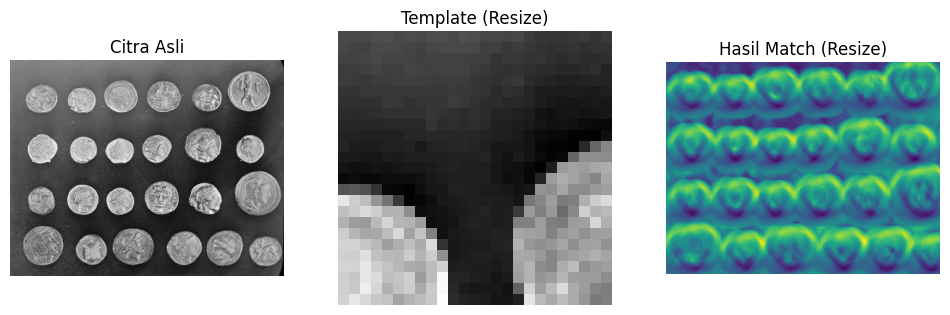

In [8]:
# Perubahan ukuran template
resized_template = transform.resize(template, (template.shape[0] // 2, template.shape[1] // 2), anti_aliasing=True)

# Lakukan pencocokan template
result_resized = match_template(image, resized_template)

# Tampilkan hasil
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(resized_template, cmap='gray')
plt.title('Template (Resize)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(result_resized, cmap='viridis')
plt.title('Hasil Match (Resize)')
plt.axis('off')

plt.show()
